In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 1. Create the Dataset
We'll generate a dataset with 3 independent variables (features) and 1 dependent variable (target). This makes it entirely transparent how the numbers are created.

In [9]:
# Generate dataset with 3 features and 1 output
X, y = make_regression(n_samples=300, n_features=3, n_targets=1, noise=15, random_state=42)

# Convert to a Pandas DataFrame to clearly see the structure
columns = ['Feature_1', 'Feature_2', 'Feature_3']
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

display(df.head())

,Feature_1,Feature_2,Feature_3,Target
0,-0.155677,0.086590,-0.603985,2.756178
1,-1.867265,2.314659,0.081874,35.051792
2,0.096996,-0.130143,0.324166,-4.764554
3,-0.530869,2.526932,1.188393,184.958173
4,0.711615,0.514439,0.120296,119.594869


### 2. Visualize the Data
Before training the model, let's visualize the relationship between each of our 3 features and the target variable. We will plot regression lines inside them.

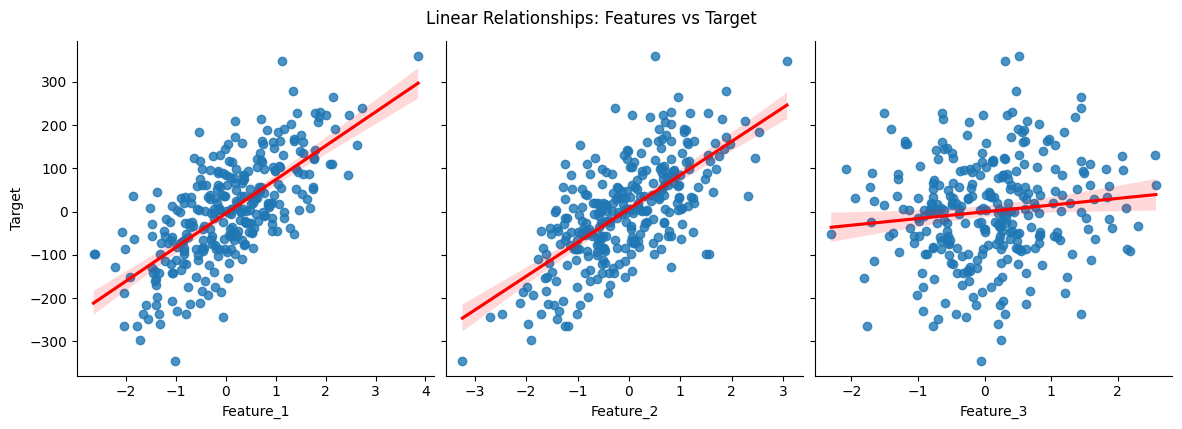

In [10]:
# Use Seaborn's pairplot to plot each feature against the target
sns.pairplot(df, x_vars=['Feature_1', 'Feature_2', 'Feature_3'], y_vars='Target', height=4, aspect=1, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle("Linear Relationships: Features vs Target", y=1.05)
plt.show()

### 3D Visualization
Since we have 3 dimensional features and 1 output, a great way to look at this is plotting the 3 features on the X, Y, and Z axes, and representing the output (Target) as the color of the points.

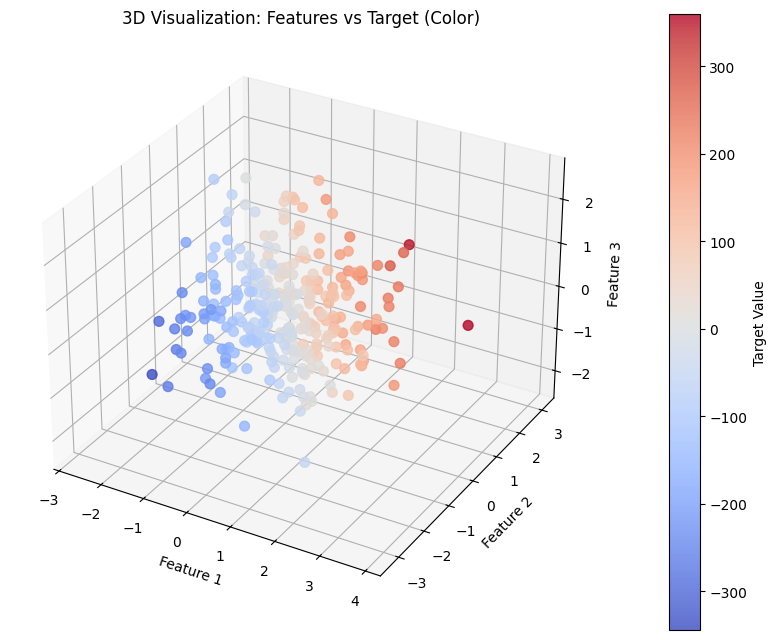

In [11]:
# Create a 3D scatter plot using matplotlib
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter points: X=Feature_1, Y=Feature_2, Z=Feature_3, Color=Target
scatter = ax.scatter(df['Feature_1'], df['Feature_2'], df['Feature_3'], 
                     c=df['Target'], cmap='coolwarm', s=50, alpha=0.8)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('3D Visualization: Features vs Target (Color)')

# Add a color bar to show the target values
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Value')

plt.show()

### 3. Model Training
Now we will split our synthesized data into a training set and a testing set, then train our Multiple Linear Regression model on the training data.

In [12]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(df[['Feature_1', 'Feature_2', 'Feature_3']], df['Target'], test_size=0.2, random_state=42)

# Create the model
model = LinearRegression()

# Train (fit) the model
model.fit(X_train, y_train)

print("Multiple Linear Regression model training successful!")

Multiple Linear Regression model training successful!


### 4. Evaluate the Model and See the Results
Finally, we can look at the mathematical results (the coefficients assigned to each feature), perform a prediction, and calculate the overall error (MSE and R-squared).

In [ ]:
# Print the formulas weights (coefficients) and bias (intercept)
print("Base Intercept (bias):", model.intercept_)
for col, coef in zip(columns, model.coef_):
    print(f"Coefficient for {col}: {coef:.4f}")

# Predict on the unseen testing data
y_pred = model.predict(X_test)

# Show statistical results
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Adjusted R-squared formula: 1 - ((1 - r2) * (n - 1) / (n - p - 1))
n = X_test.shape[0] # number of samples (rows)
p = X_test.shape[1] # number of features (columns)
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("\n--- Model Performance (All 5 Metrics) ---")
print(f"1. Mean Absolute Error (MAE): {mae:.4f}")
print(f"2. Mean Squared Error (MSE): {mse:.4f}")
print(f"3. Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"4. R-squared (R2 Score): {r2:.4f} (Closer to 1.0 is better!)")
print(f"5. Adjusted R-squared: {adj_r2:.4f}")

Base Intercept (bias): 0.54108818653625
Coefficient for Feature_1: 83.0071
Coefficient for Feature_2: 81.4859
Coefficient for Feature_3: 16.3732

--- Model Performance ---
Mean Squared Error (MSE): 170.81
R-squared (R2 Score): 0.9897 (Closer to 1.0 is better!)
